# Bondview Duration — 6M / 9M / 12M Trend Horizon Review

This notebook reviews the endpoint-based **Yield Trend** horizon while keeping the existing Duration design roles unchanged:

```text
Yield Trend
→ broader directional rates condition relevant to the exposure

Recent Yield Move
→ shorter-horizon movement that may confirm, pause, or oppose that broader condition
```

The fixed calculations in this review are:

```text
Recent Move = M5(t) - M5(t-21)     ≈ 1M

Trend 6M   = M5(t) - M5(t-126)
Trend 9M   = M5(t) - M5(t-189)
Trend 12M  = M5(t) - M5(t-252)
```

where `M5(t)` is the mean of the five valid observations ending at `t`.

## Review guardrails

- This is **not** a forecasting test.
- The internal path shape inside the Trend horizon is intentionally not reconstructed.
- The provisional thresholds are held fixed only as a research fixture:
  - Trend: ±25 bp
  - Recent Move: ±10 bp
- A longer horizon naturally changes the Trend-value distribution, so State occupancy must **not** be used mechanically to choose the horizon.
- Fewer transitions are not automatically better.
- Mixed Trend × Recent states are intentional and may be economically useful.
- Historical periods are challenge / counterexample cases, not target labels.
- The horizon decision should be made before a separate Trend State-classification review.
- The 6M candidate is the committed **Task-2 A (6M)** definition. Task-1 used the same Trend logic, so it is not treated as a separate candidate or benchmark.

The notebook uses the frozen Task-1 source snapshot and does not download new data.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

ACCEPTED_AVAILABILITY = {"available", "insufficient_130_observation_history"}

HORIZONS = {
    "6M": 126,
    "9M": 189,
    "12M": 252,
}

TREND_THRESHOLD_BP = 25.0
RECENT_THRESHOLD_BP = 10.0

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    # Common local location used for this project, if the notebook is launched elsewhere.
    candidates.append(Path("/home/lbk/works/bondview-v2"))
    seen = set()
    for p in candidates:
        p = p.resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "validation/261002_duration/task1_core/results.csv").exists():
            return p
    raise FileNotFoundError(
        "Could not find the bondview-v2 repository root. "
        "Run this notebook from inside the repository or edit REPO_ROOT manually."
    )

REPO_ROOT = find_repo_root()
TASK1 = REPO_ROOT / "validation/261002_duration/task1_core/results.csv"
TASK2 = REPO_ROOT / "validation/261002_duration/task2_trend/comparison.csv"

print("REPO_ROOT:", REPO_ROOT)
print("TASK1:", TASK1)
print("TASK2 exists:", TASK2.exists())


REPO_ROOT: /home/lbk/works/bondview-v2
TASK1: /home/lbk/works/bondview-v2/validation/261002_duration/task1_core/results.csv
TASK2 exists: True


## 1. Load the frozen source snapshot and reconstruct 6M / 9M / 12M

The historical observations are read from the frozen Task-1 CSV **only as the source snapshot**. Task-1's 6M model output is not treated as a separate benchmark because Task-2 A uses the same 6M methodology and logic.

The calculation uses **valid-observation indexing**, grouped by representative tenor and accepted structural segment. It does not interpolate calendar dates and does not bridge the 30Y structural gap.


In [2]:
task1 = pd.read_csv(TASK1, parse_dates=["as_of"])

required = {
    "as_of", "representative_tenor", "duration_exposure",
    "yield_pct", "availability", "segment"
}
missing = required - set(task1.columns)
if missing:
    raise ValueError(f"Task-1 results.csv is missing expected columns: {sorted(missing)}")

accepted = (
    task1.loc[
        task1["availability"].isin(ACCEPTED_AVAILABILITY)
        & task1["yield_pct"].notna()
        & task1["segment"].notna()
    ]
    .copy()
)

accepted["segment"] = accepted["segment"].astype(int)
accepted = accepted.sort_values(
    ["representative_tenor", "segment", "as_of"]
).reset_index(drop=True)

# Numerical tolerance only; this does not widen the economic threshold.
# Task-1 used exact decimal arithmetic, whereas pandas rolling means use binary
# floating point. Exact boundary values such as +25.0 bp can reconstruct as
# 25.00000000000001 and must still remain Stable.
BOUNDARY_EPS_BP = 1e-9

def classify(value, threshold):
    if pd.isna(value):
        return pd.NA
    if value < -threshold - BOUNDARY_EPS_BP:
        return "Falling"
    if value > threshold + BOUNDARY_EPS_BP:
        return "Rising"
    return "Stable"

parts = []
for (tenor, segment), g in accepted.groupby(
    ["representative_tenor", "segment"], sort=False
):
    g = g.sort_values("as_of").copy()
    g["valid_observation_index"] = np.arange(len(g))
    g["yield_bp"] = g["yield_pct"].astype(float) * 100.0
    g["m5_bp"] = g["yield_bp"].rolling(5, min_periods=5).mean()

    g["recent_move_bp"] = g["m5_bp"] - g["m5_bp"].shift(21)
    g["recent_move_state"] = g["recent_move_bp"].map(
        lambda x: classify(x, RECENT_THRESHOLD_BP)
    )

    for label, lag in HORIZONS.items():
        bp_col = f"trend_{label}_bp"
        state_col = f"trend_{label}_state"
        case_col = f"rule_case_{label}"

        g[bp_col] = g["m5_bp"] - g["m5_bp"].shift(lag)
        g[state_col] = g[bp_col].map(
            lambda x: classify(x, TREND_THRESHOLD_BP)
        )
        g[case_col] = (
            g[state_col].astype("string")
            + " × "
            + g["recent_move_state"].astype("string")
        )

    parts.append(g)

features_all = pd.concat(parts, ignore_index=True)

required_common = [
    "recent_move_bp",
    *[f"trend_{h}_bp" for h in HORIZONS],
]
common = (
    features_all
    .dropna(subset=required_common)
    .copy()
)

print("Accepted source observations:", len(accepted))
print("Common 6M/9M/12M + Recent observations:", len(common))
display(
    common.groupby("representative_tenor")
    .size()
    .rename("common_n")
    .to_frame()
)


Accepted source observations: 38850
Common 6M/9M/12M + Recent observations: 37826


,common_n
representative_tenor,
10Y,15916
30Y,10896
6M,11014


### Numerical boundary handling

Task-1 used exact decimal arithmetic, while this review notebook uses pandas/NumPy floating-point rolling means. A tiny `1e-9 bp` tolerance is applied only when classifying exact boundaries, so values that are economically exactly `+25.0/-25.0 bp` for Trend or `+10.0/-10.0 bp` for Recent remain `Stable`. This is numerical hygiene, not a wider State threshold.


## 2. Sanity check: reconstructed 6M versus committed Task-2 A (6M)

Task-2 A uses the same 6M Trend definition as Task-1, so Task-1 is **not** shown as a separate comparison. It would be a duplicate methodological reference.

This cell checks only that the notebook's reconstructed 6M calculation reproduces the committed **Task-2 A (6M)** result. A pass is an implementation sanity check, not an economic finding.


In [3]:
checks = []
mismatch_details = []

if not TASK2.exists():
    raise FileNotFoundError(f"Committed Task-2 comparison not found: {TASK2}")

task2 = pd.read_csv(TASK2, parse_dates=["as_of"])
expected = {
    "as_of",
    "representative_tenor",
    "A_trend_bp",
    "A_trend_state",
}
missing = expected - set(task2.columns)
if missing:
    raise ValueError(
        f"Task-2 comparison.csv is missing expected columns: {sorted(missing)}"
    )

t2 = (
    task2[
        [
            "as_of",
            "representative_tenor",
            "A_trend_bp",
            "A_trend_state",
        ]
    ]
    .rename(
        columns={
            "A_trend_bp": "task2_6M_bp",
            "A_trend_state": "task2_6M_state",
        }
    )
    .copy()
)

merged2 = common[
    [
        "as_of",
        "representative_tenor",
        "trend_6M_bp",
        "trend_6M_state",
    ]
].merge(
    t2,
    on=["as_of", "representative_tenor"],
    how="inner",
    validate="one_to_one",
)

max_abs_diff2 = (
    merged2["trend_6M_bp"] - merged2["task2_6M_bp"]
).abs().max()

mismatch_mask2 = (
    merged2["trend_6M_state"].astype("string")
    != merged2["task2_6M_state"].astype("string")
)
state_mismatch2 = int(mismatch_mask2.sum())

checks.append({
    "source": "Task-2 A (6M)",
    "matched_rows": len(merged2),
    "max_abs_bp_difference": max_abs_diff2,
    "state_mismatches": state_mismatch2,
})

if state_mismatch2:
    details2 = merged2.loc[mismatch_mask2].copy()
    details2.insert(0, "source", "Task-2 A (6M)")
    mismatch_details.append(details2)

check_df = pd.DataFrame(checks)
display(check_df)

if mismatch_details:
    print("State mismatches found; showing the first rows before assertion:")
    display(pd.concat(mismatch_details, ignore_index=True).head(100))

assert (check_df["max_abs_bp_difference"].fillna(0) < 1e-9).all()
assert (check_df["state_mismatches"] == 0).all()


,source,matched_rows,max_abs_bp_difference,state_mismatches
0,Task-2 A (6M),37826,2.735590e-13,0


**Interpretation:** a pass here means only that this notebook reproduces the already-defined 6M calculation. It does **not** provide evidence for or against the 6M horizon.


## 3. Continuous Trend-value distributions

**Key conclusion:** a longer horizon mechanically produces larger absolute Trend values. With the same ±25 bp threshold, that alone creates more directional States.

The chart below shows the scale effect; it does **not** choose the preferred horizon.


In [4]:
distribution_rows = []

for tenor, g in common.groupby("representative_tenor"):
    for horizon in HORIZONS:
        s = g[f"trend_{horizon}_bp"].astype(float)
        abs_s = s.abs()
        distribution_rows.append({
            "tenor": tenor,
            "horizon": horizon,
            "n": len(s),
            "mean_bp": s.mean(),
            "median_bp": s.median(),
            "std_bp": s.std(),
            "median_abs_bp": abs_s.median(),
            "p75_abs_bp": abs_s.quantile(0.75),
            "p90_abs_bp": abs_s.quantile(0.90),
            "min_bp": s.min(),
            "max_bp": s.max(),
        })

distribution_summary = pd.DataFrame(distribution_rows)
display(distribution_summary.round(2))


,tenor,horizon,n,mean_bp,median_bp,std_bp,median_abs_bp,p75_abs_bp,p90_abs_bp,min_bp,max_bp
0,10Y,6M,15916,0.50,2.8,80.85,45.8,81.6,124.80,-428.0,431.0
1,10Y,9M,15916,0.63,4.4,97.88,55.2,98.6,149.10,-426.6,409.8
2,10Y,12M,15916,0.66,7.2,115.24,68.0,112.4,177.60,-480.4,440.6
3,30Y,6M,10896,-2.60,-3.2,81.08,45.4,79.6,125.20,-375.6,376.4
4,30Y,9M,10896,-3.95,-4.9,99.40,57.2,97.6,153.40,-415.8,362.4
5,30Y,12M,10896,-5.36,-4.8,116.66,64.0,112.6,187.90,-437.0,373.8
6,6M,6M,11014,-10.18,-2.8,99.11,42.2,96.8,158.60,-594.2,316.8
7,6M,9M,11014,-15.99,-4.4,132.11,66.6,139.4,205.00,-649.2,411.0
8,6M,12M,11014,-22.04,-7.0,161.90,83.8,176.2,271.34,-729.6,462.0


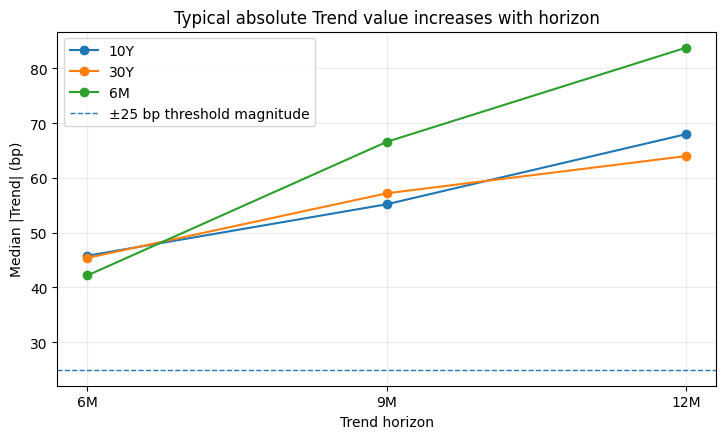

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))

for tenor, g in distribution_summary.groupby("tenor", sort=False):
    g = g.set_index("horizon").loc[list(HORIZONS)]
    ax.plot(
        g.index,
        g["median_abs_bp"],
        marker="o",
        label=f"{tenor}",
    )

ax.axhline(TREND_THRESHOLD_BP, linestyle="--", linewidth=1, label="±25 bp threshold magnitude")
ax.set_title("Typical absolute Trend value increases with horizon")
ax.set_xlabel("Trend horizon")
ax.set_ylabel("Median |Trend| (bp)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


**Result:** the scale effect is large and monotonic. For 10Y, median `|Trend|` rises from **45.8 bp → 55.2 bp → 68.0 bp** across 6M / 9M / 12M; for the 6M tenor it rises from **42.2 bp → 66.6 bp → 83.8 bp**.

A useful counterexample to “more directional States means a better Trend” is therefore immediate: a 12M Trend will cross the unchanged ±25 bp boundary more often partly because its raw value is larger by construction. That is not evidence that 12M is economically better.


## 4. State occupancy under the fixed ±25 bp research threshold

The threshold is deliberately held fixed to isolate the horizon comparison. Different occupancy across 6M / 9M / 12M is therefore partly a scale effect and is **not** a target to optimize.


In [6]:
occupancy_rows = []

for tenor, g in common.groupby("representative_tenor"):
    for horizon in HORIZONS:
        counts = g[f"trend_{horizon}_state"].value_counts()
        n = len(g)
        occupancy_rows.append({
            "tenor": tenor,
            "horizon": horizon,
            "Falling_%": 100 * counts.get("Falling", 0) / n,
            "Stable_%": 100 * counts.get("Stable", 0) / n,
            "Rising_%": 100 * counts.get("Rising", 0) / n,
        })

state_occupancy = pd.DataFrame(occupancy_rows)
display(state_occupancy.round(2))


,tenor,horizon,Falling_%,Stable_%,Rising_%
0,10Y,6M,33.19,30.60,36.22
1,10Y,9M,36.55,24.58,38.87
2,10Y,12M,37.85,19.52,42.63
3,30Y,6M,37.12,28.17,34.71
4,30Y,9M,39.63,22.41,37.96
5,30Y,12M,41.41,19.81,38.78
6,6M,6M,31.27,39.28,29.45
7,6M,9M,36.60,32.06,31.34
8,6M,12M,40.55,25.92,33.53


**Result:** `Stable` occupancy falls at every tenor as the horizon lengthens. For 10Y it falls from **30.6% (6M)** to **24.6% (9M)** to **19.5% (12M)**; for 30Y, **28.2% → 22.4% → 19.8%**.

This mostly confirms the scale effect above. Do not read the lower `Stable` share as evidence favoring 9M or 12M.


## 5. Transition frequency and State persistence

The core quantitative question is whether each Trend candidate remains materially broader/slower than the fixed 1M Recent Move.

Lower transition frequency is descriptive, **not automatically better**.


In [12]:
def episode_lengths(frame, state_col):
    lengths = []
    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of")
        s = g[state_col].astype("string")
        episode_id = s.ne(s.shift()).cumsum()
        lengths.extend(g.groupby(episode_id).size().tolist())
    return np.asarray(lengths, dtype=int)

def transition_rate(frame, state_col):
    changes = 0
    pairs = 0
    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of")
        s = g[state_col].astype("string").to_numpy()
        if len(s) < 2:
            continue
        pairs += len(s) - 1
        changes += np.count_nonzero(s[1:] != s[:-1])
    return changes, pairs, (changes / pairs if pairs else np.nan)

persistence_rows = []

for tenor, g in common.groupby("representative_tenor"):
    g = g.copy()

    # Recent Move reference.
    changes, pairs, rate = transition_rate(g, "recent_move_state")
    lens = episode_lengths(g, "recent_move_state")
    persistence_rows.append({
        "tenor": tenor,
        "series": "Recent 1M",
        "transitions": changes,
        "eligible_pairs": pairs,
        "transition_%": 100 * rate,
        "episodes": len(lens),
        "median_n": np.median(lens),
        "p90_n": np.quantile(lens, 0.90, method="higher"),
        "max_n": lens.max(),
    })

    for horizon in HORIZONS:
        state_col = f"trend_{horizon}_state"
        changes, pairs, rate = transition_rate(g, state_col)
        lens = episode_lengths(g, state_col)
        persistence_rows.append({
            "tenor": tenor,
            "series": f"Trend {horizon}",
            "transitions": changes,
            "eligible_pairs": pairs,
            "transition_%": 100 * rate,
            "episodes": len(lens),
            "median_n": np.median(lens),
            "p90_n": np.quantile(lens, 0.90, method="higher"),
            "max_n": lens.max(),
        })

persistence_summary = pd.DataFrame(persistence_rows)
display(persistence_summary.round(2))


,tenor,series,transitions,eligible_pairs,transition_%,episodes,median_n,p90_n,max_n
0,10Y,Recent 1M,1157,15915,7.27,1158,8.0,31,403
1,10Y,Trend 6M,459,15915,2.88,460,15.0,93,707
2,10Y,Trend 9M,399,15915,2.51,400,14.0,105,744
3,10Y,Trend 12M,289,15915,1.82,290,16.0,211,705
4,30Y,Recent 1M,847,10894,7.77,849,8.0,29,102
5,30Y,Trend 6M,326,10894,2.99,328,14.0,103,346
6,30Y,Trend 9M,292,10894,2.68,294,11.0,92,525
7,30Y,Trend 12M,235,10894,2.16,236,13.5,127,543
8,6M,Recent 1M,485,11013,4.40,486,11.0,44,1567
9,6M,Trend 6M,178,11013,1.62,179,12.0,158,1534


**Result:** all three Trend candidates are already much slower than Recent Move. For 10Y, transition rates are **2.88% / 2.51% / 1.82%** for 6M / 9M / 12M versus **7.27%** for Recent; for 30Y they are **2.99% / 2.68% / 2.16%** versus **7.77%**.

So a longer horizon is **not needed merely to make Trend distinct from Recent Move**. The extra persistence of 9M/12M must justify itself economically, especially during reversals.


## 6. Trend / Recent temporal separation

Useful diagnostics:

- **Exact agreement**: Trend and Recent have the same State.
- **Opposing direction**: `Rising × Falling` or `Falling × Rising`.
- **Mixed**: any Trend / Recent State disagreement.
- **Recent changes while Trend stays unchanged**: direct evidence that Recent is operating at a shorter timescale.

None of these is an optimization target.


In [7]:
def recent_changes_while_trend_same(frame, trend_state_col):
    recent_changes = 0
    trend_same_on_recent_change = 0

    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of")
        rs = g["recent_move_state"].astype("string").to_numpy()
        ts = g[trend_state_col].astype("string").to_numpy()

        if len(g) < 2:
            continue

        recent_change_mask = rs[1:] != rs[:-1]
        recent_changes += recent_change_mask.sum()

        if recent_change_mask.any():
            trend_same = ts[1:] == ts[:-1]
            trend_same_on_recent_change += (
                recent_change_mask & trend_same
            ).sum()

    return (
        recent_changes,
        trend_same_on_recent_change,
        100 * trend_same_on_recent_change / recent_changes
        if recent_changes else np.nan
    )

separation_rows = []

for tenor, g in common.groupby("representative_tenor"):
    for horizon in HORIZONS:
        ts = g[f"trend_{horizon}_state"].astype("string")
        rs = g["recent_move_state"].astype("string")

        exact = (ts == rs)
        opposing = (
            ((ts == "Rising") & (rs == "Falling"))
            | ((ts == "Falling") & (rs == "Rising"))
        )
        mixed = ts != rs

        recent_changes, stayed, stayed_pct = (
            recent_changes_while_trend_same(
                g, f"trend_{horizon}_state"
            )
        )

        separation_rows.append({
            "tenor": tenor,
            "horizon": horizon,
            "exact_agreement_%": 100 * exact.mean(),
            "opposing_direction_%": 100 * opposing.mean(),
            "all_mixed_%": 100 * mixed.mean(),
            "recent_state_changes": recent_changes,
            "recent_changes_with_trend_unchanged": stayed,
            "recent_changes_with_trend_unchanged_%": stayed_pct,
        })

separation_summary = pd.DataFrame(separation_rows)
display(separation_summary.round(2))


,tenor,horizon,exact_agreement_%,opposing_direction_%,all_mixed_%,recent_state_changes,recent_changes_with_trend_unchanged,recent_changes_with_trend_unchanged_%
0,10Y,6M,49.42,14.11,50.58,1157,1126,97.32
1,10Y,9M,47.21,16.93,52.79,1157,1127,97.41
2,10Y,12M,46.36,19.75,53.64,1157,1138,98.36
3,30Y,6M,47.67,13.55,52.33,847,813,95.99
4,30Y,9M,44.87,17.86,55.13,847,812,95.87
5,30Y,12M,42.85,20.08,57.15,847,829,97.87
6,6M,6M,62.89,7.63,37.11,485,473,97.53
7,6M,9M,57.83,9.65,42.17,485,475,97.94
8,6M,12M,53.07,11.01,46.93,485,472,97.32


**Result:** roughly **96–98% of Recent-Move State changes occur while Trend stays unchanged** for every tested horizon. Even the 6M Trend therefore already provides strong temporal separation from Recent Move.

Longer horizons reduce exact agreement and increase opposing-direction cases, but “more disagreement” is not automatically more information; it can also mean the Trend is retaining an older regime.


## 7. Opposing-direction episode duration

Long opposing episodes are not automatically failures. They can be exactly the intended representation of:

```text
broader Rising Trend + shorter Falling Recent Move
```

or the reverse.

This table shows how persistent those opposing cases are under each Trend horizon.


In [8]:
OPPOSING_CASES = {"Rising × Falling", "Falling × Rising"}

def case_episode_lengths(frame, case_col, allowed_cases):
    rows = []
    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of").copy()
        s = g[case_col].astype("string")
        episode_id = s.ne(s.shift()).cumsum()

        for _, ep in g.groupby(episode_id):
            case = str(ep[case_col].iloc[0])
            if case in allowed_cases:
                rows.append((case, len(ep)))
    return rows

opposing_rows = []

for tenor, g in common.groupby("representative_tenor"):
    for horizon in HORIZONS:
        episodes = case_episode_lengths(
            g, f"rule_case_{horizon}", OPPOSING_CASES
        )
        for case in sorted(OPPOSING_CASES):
            lens = np.asarray(
                [n for c, n in episodes if c == case],
                dtype=int
            )
            opposing_rows.append({
                "tenor": tenor,
                "horizon": horizon,
                "case": case,
                "episodes": len(lens),
                "observations": int(lens.sum()) if len(lens) else 0,
                "median_n": np.median(lens) if len(lens) else np.nan,
                "p90_n": (
                    np.quantile(lens, 0.90, method="higher")
                    if len(lens) else np.nan
                ),
                "max_n": lens.max() if len(lens) else np.nan,
            })

opposing_episode_summary = pd.DataFrame(opposing_rows)
display(opposing_episode_summary.round(2))


,tenor,horizon,case,episodes,observations,median_n,p90_n,max_n
0,10Y,6M,Falling × Rising,104,1083,6.0,25,68
1,10Y,6M,Rising × Falling,120,1162,7.0,21,34
2,10Y,9M,Falling × Rising,126,1292,7.0,24,35
3,10Y,9M,Rising × Falling,124,1402,8.5,26,52
4,10Y,12M,Falling × Rising,128,1430,7.0,25,67
5,10Y,12M,Rising × Falling,129,1713,10.0,29,52
6,30Y,6M,Falling × Rising,87,787,6.0,20,60
7,30Y,6M,Rising × Falling,78,689,5.5,20,35
8,30Y,9M,Falling × Rising,92,937,7.0,22,37
9,30Y,9M,Rising × Falling,90,1009,6.5,24,64


**Result:** opposing-direction episodes generally become more persistent as the Trend horizon lengthens. For example, in 10Y `Rising × Falling` observations increase from **1,162 (6M)** to **1,713 (12M)**, with median episode length rising from **7** to **10** observations.

That can be useful broad-vs-recent separation, but it is also exactly where a stale-Trend failure can hide. The historical challenge review below is needed to distinguish those two interpretations.


## 8. How often do the horizons change the Rule Case?

Recent Move is fixed, so differences here come from the Trend horizon.

This is downstream sensitivity, not a performance score.


In [9]:
pairs = [("6M", "9M"), ("6M", "12M"), ("9M", "12M")]
pairwise_rows = []

for tenor, g in common.groupby("representative_tenor"):
    for left, right in pairs:
        changed = (
            g[f"rule_case_{left}"].astype("string")
            != g[f"rule_case_{right}"].astype("string")
        )
        pairwise_rows.append({
            "tenor": tenor,
            "comparison": f"{left} vs {right}",
            "changed_n": int(changed.sum()),
            "changed_%": 100 * changed.mean(),
        })

pairwise_rule_case_changes = pd.DataFrame(pairwise_rows)
display(pairwise_rule_case_changes.round(2))


,tenor,comparison,changed_n,changed_%
0,10Y,6M vs 9M,5132,32.24
1,10Y,6M vs 12M,6001,37.70
2,10Y,9M vs 12M,4182,26.28
3,30Y,6M vs 9M,3443,31.60
4,30Y,6M vs 12M,4219,38.72
5,30Y,9M vs 12M,3074,28.21
6,6M,6M vs 9M,1943,17.64
7,6M,6M vs 12M,2780,25.24
8,6M,9M vs 12M,1566,14.22


**Result:** the horizon choice materially changes downstream Rule Cases. For 10Y, **32.2%** of dates differ between 6M and 9M and **37.7%** between 6M and 12M; 30Y is similar at **31.6%** and **38.7%**.

So 6M / 9M / 12M is not a cosmetic parameter choice. It changes the inputs seen by Duration Evaluation often enough that the historical counterexamples matter.


## 9. Same-date cross-tenor disagreement

Different representative tenors are allowed to produce different local conditions. This table is included only to confirm that changing the Trend horizon does not accidentally collapse the exposure-local structure.


In [10]:
cross_tenor_rows = []

for horizon in HORIZONS:
    pivot = (
        common.pivot_table(
            index="as_of",
            columns="representative_tenor",
            values=f"rule_case_{horizon}",
            aggfunc="first",
        )
        .dropna(subset=["6M", "10Y", "30Y"])
    )
    distinct = pivot.nunique(axis=1)
    cross_tenor_rows.append({
        "horizon": horizon,
        "common_dates": len(pivot),
        "one_case_%": 100 * (distinct == 1).mean(),
        "exactly_two_cases_%": 100 * (distinct == 2).mean(),
        "three_distinct_cases_%": 100 * (distinct == 3).mean(),
        "any_disagreement_%": 100 * (distinct > 1).mean(),
    })

cross_tenor_summary = pd.DataFrame(cross_tenor_rows)
display(cross_tenor_summary.round(2))


,horizon,common_dates,one_case_%,exactly_two_cases_%,three_distinct_cases_%,any_disagreement_%
0,6M,9764,23.48,59.66,16.86,76.52
1,9M,9764,23.91,59.75,16.34,76.09
2,12M,9764,24.33,59.66,16.01,75.67


**Result:** cross-tenor disagreement remains almost unchanged at about **76%** under all three horizons. The exposure-local structure therefore does **not** collapse when the Trend horizon changes.

This is mainly a safety check, not a horizon-selection criterion.


# Historical challenge review

Each event uses **two aligned panels** so that the broad Trend comparison is not visually mixed with Recent Move:

1. **Trend panel** — 6M / 9M / 12M Trend values on the left axis, with the underlying Treasury yield on the right axis.
2. **Recent Move panel** — fixed 1M Recent Move on the left axis, with the same underlying Treasury yield on the right axis.

The underlying yield is shown as a neutral gray dashed line in both panels. The Trend ±25 bp and Recent ±10 bp research boundaries are shown only in their corresponding panels.

Categorical `Falling / Stable / Rising` States are **not overlaid on the charts**. When State timing matters, inspect the returned transition table instead:

```python
event_reviews["1980_10Y"]["transitions"]
event_reviews["2022_10Y"]["case_occupancy"]
```

`review_event()` returns the event frame, exact State-transition table, and Rule Case occupancy; it does not automatically display those tables.

The historical events are **challenge / counterexample cases, not target labels**. Their purpose is to test whether a longer horizon adds useful broad-condition context or merely leaves an old regime in place too long.


In [11]:
EVENTS = [
    {
        "key": "1980_10Y",
        "label": "1980 reversal — 10Y (model-derived diagnostic)",
        "tenor": "10Y",
        "start": "1980-01-01",
        "end": "1980-12-31",
    },
    {
        "key": "1980_30Y",
        "label": "1980 reversal — 30Y (model-derived diagnostic)",
        "tenor": "30Y",
        "start": "1980-01-01",
        "end": "1980-12-31",
    },
    {
        "key": "1981_10Y",
        "label": "1981 Volcker tightening / long-rate peak — 10Y",
        "tenor": "10Y",
        "start": "1981-07-01",
        "end": "1981-10-31",
    },
    {
        "key": "1987_10Y",
        "label": "1987 pre-crash pressure / reversal — 10Y",
        "tenor": "10Y",
        "start": "1987-08-01",
        "end": "1987-10-31",
    },
    {
        "key": "1994_10Y",
        "label": "1994 tightening / selloff — 10Y",
        "tenor": "10Y",
        "start": "1994-02-01",
        "end": "1994-11-30",
    },
    {
        "key": "1998_10Y",
        "label": "1998 Russia / LTCM flight to quality — 10Y",
        "tenor": "10Y",
        "start": "1998-08-01",
        "end": "1998-10-31",
    },
    {
        "key": "2008_10Y",
        "label": "2008 GFC / Treasury flight to quality — 10Y",
        "tenor": "10Y",
        "start": "2008-09-01",
        "end": "2008-12-31",
    },
    {
        "key": "2013_10Y",
        "label": "2013 taper tantrum — 10Y",
        "tenor": "10Y",
        "start": "2013-05-01",
        "end": "2013-09-30",
    },
    {
        "key": "2020_10Y",
        "label": "2020 COVID Treasury shock — 10Y",
        "tenor": "10Y",
        "start": "2020-02-01",
        "end": "2020-03-31",
    },
    {
        "key": "2022_10Y",
        "label": "2022 tightening + midsummer relief — 10Y",
        "tenor": "10Y",
        "start": "2022-01-01",
        "end": "2022-11-30",
    },
    {
        "key": "2023_30Y",
        "label": "2023 long-end selloff — 30Y",
        "tenor": "30Y",
        "start": "2023-07-01",
        "end": "2023-10-31",
    },
]

STATE_ORDER = ["Falling", "Stable", "Rising"]
event_reviews = {}

def event_frame(tenor, start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    return (
        common.loc[
            (common["representative_tenor"] == tenor)
            & common["as_of"].between(start, end)
        ]
        .sort_values("as_of")
        .copy()
    )

def transition_table(frame):
    series = [
        ("Recent 1M", "recent_move_state", "recent_move_bp"),
        ("Trend 6M", "trend_6M_state", "trend_6M_bp"),
        ("Trend 9M", "trend_9M_state", "trend_9M_bp"),
        ("Trend 12M", "trend_12M_state", "trend_12M_bp"),
    ]

    rows = []
    for label, state_col, value_col in series:
        prev = None
        for _, r in frame.iterrows():
            state = r[state_col]
            if state != prev:
                rows.append({
                    "series": label,
                    "date": r["as_of"],
                    "state": state,
                    "value_bp": r[value_col],
                })
                prev = state

    return (
        pd.DataFrame(rows)
        .sort_values(["date", "series"])
        .reset_index(drop=True)
    )

def event_case_occupancy(frame):
    rows = []
    for horizon in HORIZONS:
        counts = frame[f"rule_case_{horizon}"].value_counts()
        for case, n in counts.items():
            rows.append({
                "horizon": horizon,
                "rule_case": case,
                "n": int(n),
                "pct": 100 * n / len(frame),
            })
    return pd.DataFrame(rows).sort_values(
        ["horizon", "rule_case"]
    ).reset_index(drop=True)

def review_event(label, tenor, start, end):
    frame = event_frame(tenor, start, end)
    if frame.empty:
        raise ValueError(f"No common-sample observations for {label}")

    print(
        f"{label} | {tenor}: "
        f"{frame['as_of'].min().date()} to {frame['as_of'].max().date()} "
        f"| n={len(frame)}"
    )

    fig, (ax_trend, ax_recent) = plt.subplots(
        2, 1,
        figsize=(13, 8.0),
        sharex=True,
    )

    # Panel 1: 6M / 9M / 12M Trend comparison.
    for horizon in HORIZONS:
        ax_trend.plot(
            frame["as_of"],
            frame[f"trend_{horizon}_bp"],
            linewidth=1.6,
            label=f"Trend {horizon}",
        )

    ax_trend.axhline(
        TREND_THRESHOLD_BP,
        linestyle="--",
        linewidth=1,
        label="Trend ±25 bp",
    )
    ax_trend.axhline(
        -TREND_THRESHOLD_BP,
        linestyle="--",
        linewidth=1,
    )
    ax_trend.axhline(0, linewidth=0.8)
    ax_trend.set_ylabel("Trend (bp)")
    ax_trend.set_title("Trend horizon comparison")
    ax_trend.grid(True, alpha=0.25)

    ax_trend_yield = ax_trend.twinx()
    ax_trend_yield.plot(
        frame["as_of"],
        frame["yield_pct"],
        color="0.25",
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label=f"{tenor} Treasury yield",
    )
    ax_trend_yield.set_ylabel("Treasury yield (%)")

    h1, l1 = ax_trend.get_legend_handles_labels()
    h2, l2 = ax_trend_yield.get_legend_handles_labels()
    ax_trend.legend(h1 + h2, l1 + l2, loc="best")

    # Panel 2: Recent Move isolated from the Trend horizon comparison.
    ax_recent.plot(
        frame["as_of"],
        frame["recent_move_bp"],
        linewidth=1.7,
        label="Recent Move 1M",
    )
    ax_recent.axhline(
        RECENT_THRESHOLD_BP,
        linestyle="--",
        linewidth=1,
        label="Recent ±10 bp",
    )
    ax_recent.axhline(
        -RECENT_THRESHOLD_BP,
        linestyle="--",
        linewidth=1,
    )
    ax_recent.axhline(0, linewidth=0.8)
    ax_recent.set_xlabel("Date")
    ax_recent.set_ylabel("Recent Move (bp)")
    ax_recent.set_title("Recent Move")
    ax_recent.grid(True, alpha=0.25)

    ax_recent_yield = ax_recent.twinx()
    ax_recent_yield.plot(
        frame["as_of"],
        frame["yield_pct"],
        color="0.25",
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label=f"{tenor} Treasury yield",
    )
    ax_recent_yield.set_ylabel("Treasury yield (%)")

    h1, l1 = ax_recent.get_legend_handles_labels()
    h2, l2 = ax_recent_yield.get_legend_handles_labels()
    ax_recent.legend(h1 + h2, l1 + l2, loc="best")

    fig.suptitle(label, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    transitions = transition_table(frame).round({"value_bp": 1})
    case_occupancy = event_case_occupancy(frame).round({"pct": 2})

    return {
        "frame": frame,
        "transitions": transitions,
        "case_occupancy": case_occupancy,
    }


## 10. 1980 reversal — 10Y

**Review focus:** this is the main inertia counterexample. Check whether 9M or 12M keeps the old broad State long after the shorter-horizon move has become economically substantial.


1980 reversal — 10Y (model-derived diagnostic) | 10Y: 1980-01-02 to 1980-12-31 | n=250


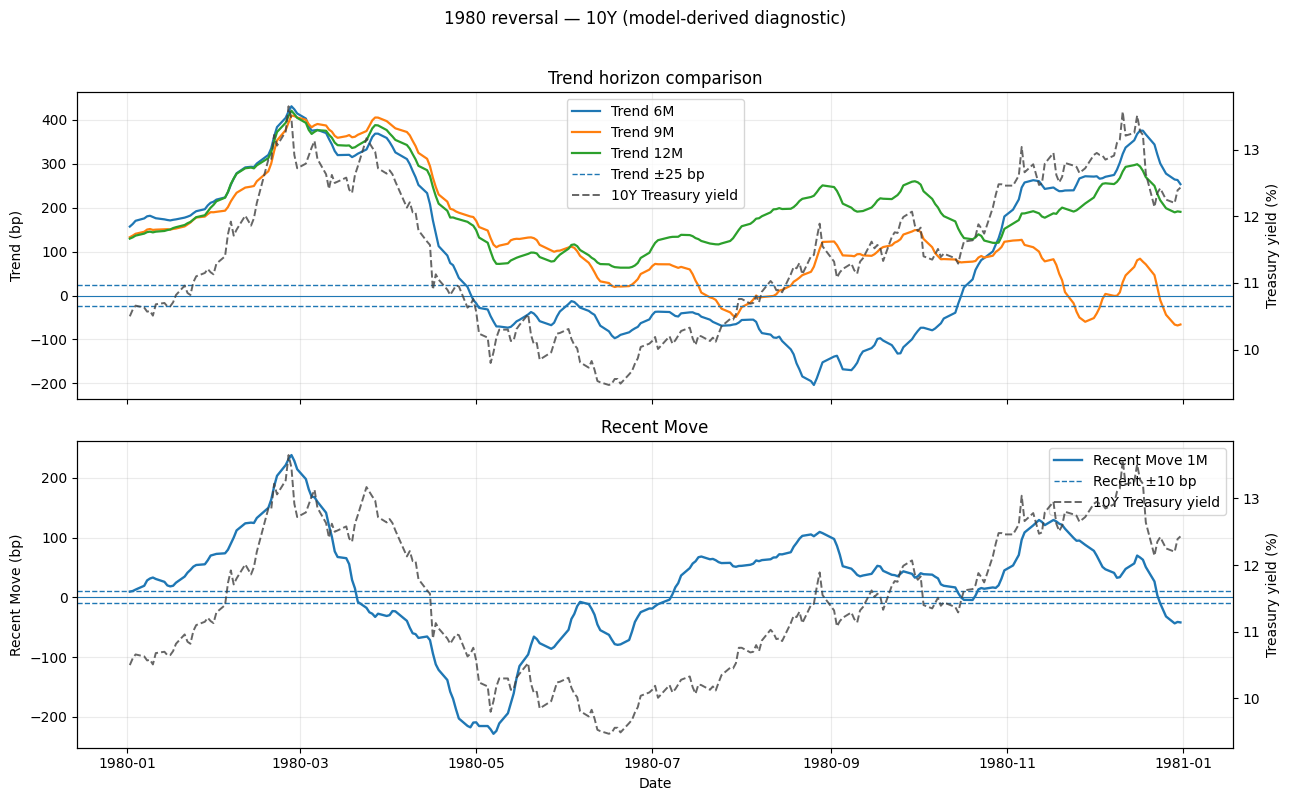

In [12]:
e = EVENTS[0]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 11. 1980 reversal — 30Y

**Review focus:** same reversal test on the long end. A longer horizon is useful only if the extra persistence still describes the current broad condition rather than a stale one.


In [ ]:
e = EVENTS[1]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 12. 1981 Volcker peak

**Review focus:** test whether a longer Trend adds useful context around a sustained high-rate regime and its turn, rather than merely delaying recognition of the turn.


In [ ]:
e = EVENTS[2]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 13. 1987 reversal

**Review focus:** a relatively fast reversal is a challenge case for inertia and boundary behavior. Look for short-lived State changes versus genuinely delayed recognition.


In [ ]:
e = EVENTS[3]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 14. 1994 tightening

**Review focus:** this sustained selloff is an anchor case. All viable horizons should eventually show the broad rising-yield condition; the useful difference is how much recognition is delayed.


In [ ]:
e = EVENTS[4]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 15. 1998 Russia / LTCM

**Review focus:** abrupt flight-to-quality tests whether longer horizons preserve useful prior context or remain attached to the pre-shock regime for too long.


In [ ]:
e = EVENTS[5]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 16. 2008 GFC

**Review focus:** a major regime reversal. This is a strong counterexample candidate if 9M/12M continue to describe the old rate direction after the broad move has clearly changed.


In [ ]:
e = EVENTS[6]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 17. 2013 taper tantrum

**Review focus:** test a multi-month long-rate selloff. If 6M already captures the broad condition while remaining distinct from Recent Move, extra horizon length needs a separate benefit.


In [ ]:
e = EVENTS[7]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 18. 2020 COVID

**Review focus:** an abrupt shock should expose excessive inertia quickly. The question is not which horizon reacts first, but when persistence stops being an economically useful broad-condition description.


In [ ]:
e = EVENTS[8]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 19. 2022 tightening + midsummer relief

**Review focus:** this is the main counterexample to “longer separation is automatically better.” If 6M already remains broadly `Rising` while Recent turns `Falling`, 9M/12M must add something beyond simply preserving the old direction longer.


2022 tightening + midsummer relief — 10Y | 10Y: 2022-01-03 to 2022-11-30 | n=228


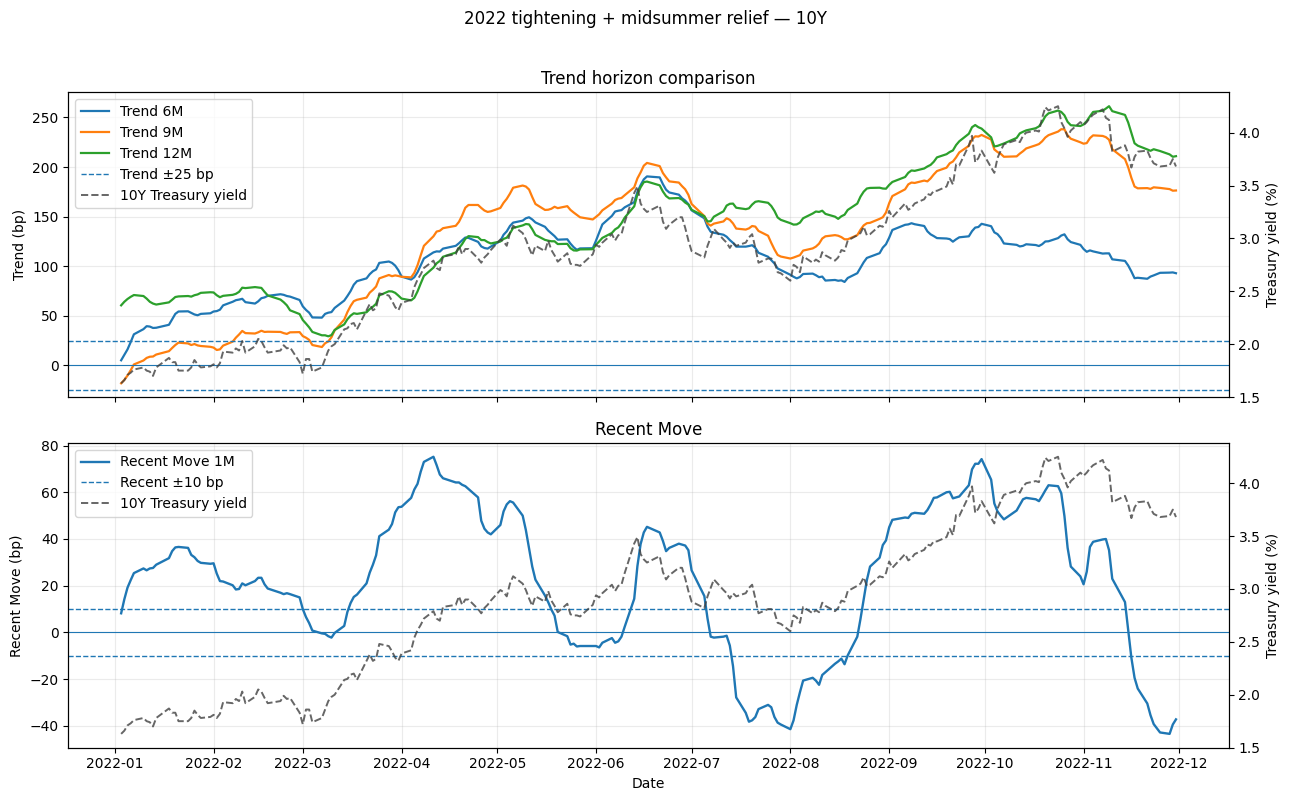

In [13]:
e = EVENTS[9]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


## 20. 2023 long-end selloff

**Review focus:** test whether the 30Y broad selloff is represented without unnecessary delay. Compare responsiveness with the need to stay clearly slower than Recent Move.


2023 long-end selloff — 30Y | 30Y: 2023-07-03 to 2023-10-31 | n=84


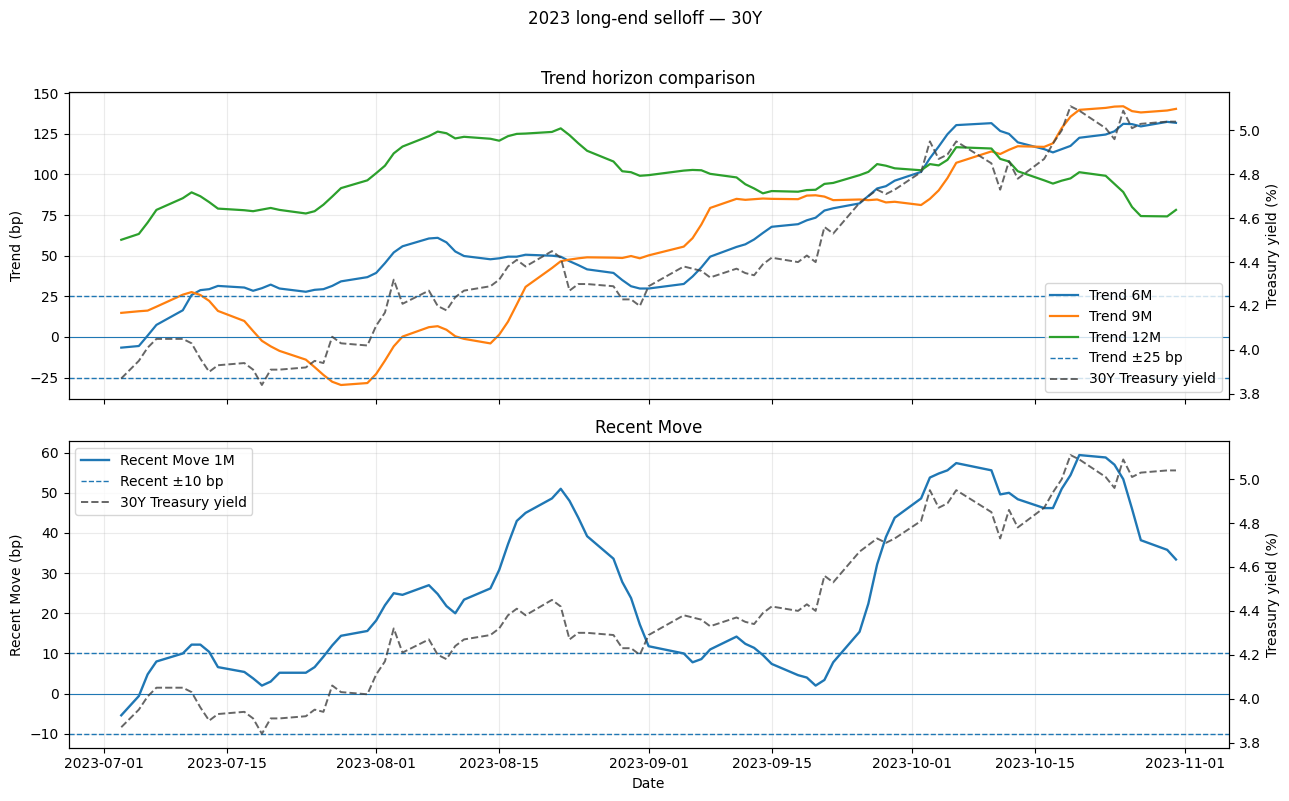

In [14]:
e = EVENTS[10]
event_reviews[e["key"]] = review_event(
    e["label"], e["tenor"], e["start"], e["end"]
)


# As-of inspection helper

Full historical windows are useful for comparison, but they can encourage hindsight.

The helper below truncates the yield chart at a selected date and prints the 6M / 9M / 12M Trend and Recent Move values **as known on that date**.

The pre-filled examples focus on the main opposing diagnostics discussed during the horizon review.


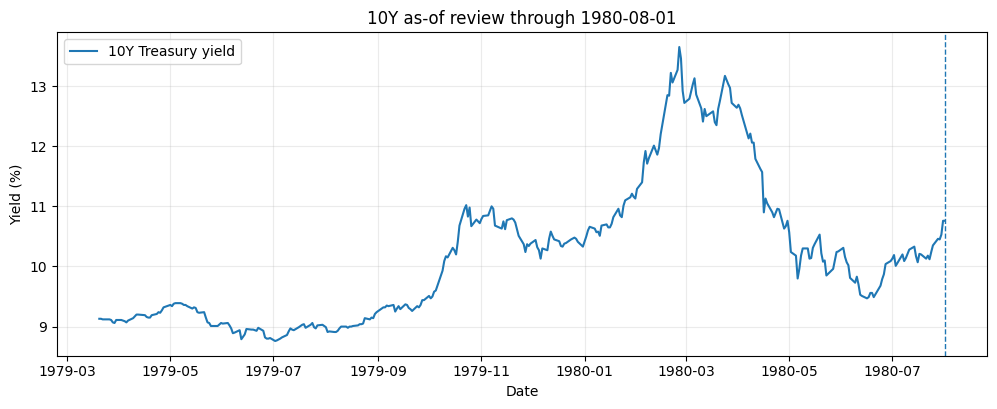

,series,value_bp,state
0,Recent 1M,52.8,Rising
1,Trend 6M,-55.8,Falling
2,Trend 9M,-26.4,Falling
3,Trend 12M,157.8,Rising


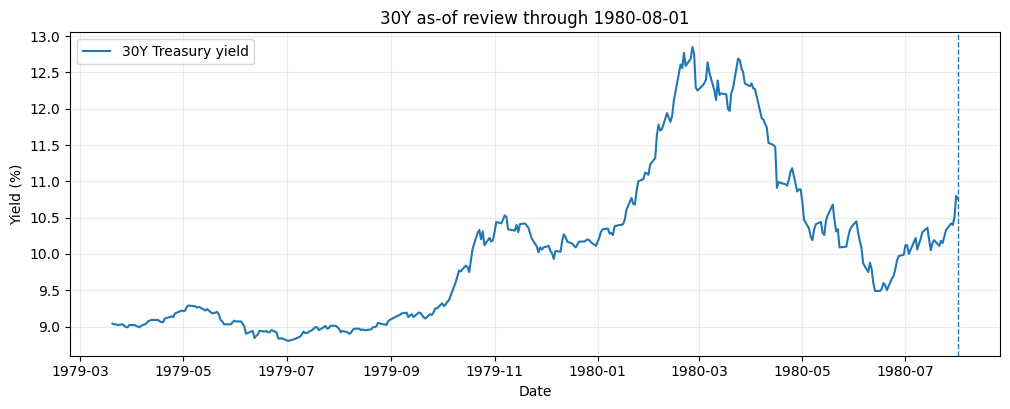

,series,value_bp,state
0,Recent 1M,55.6,Rising
1,Trend 6M,-49.2,Falling
2,Trend 9M,34.2,Rising
3,Trend 12M,158.2,Rising


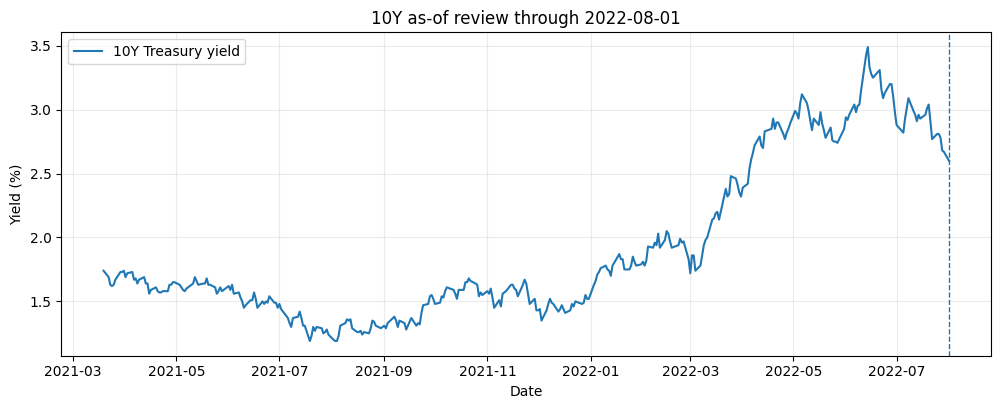

,series,value_bp,state
0,Recent 1M,-41.4,Falling
1,Trend 6M,91.4,Rising
2,Trend 9M,107.8,Rising
3,Trend 12M,143.4,Rising


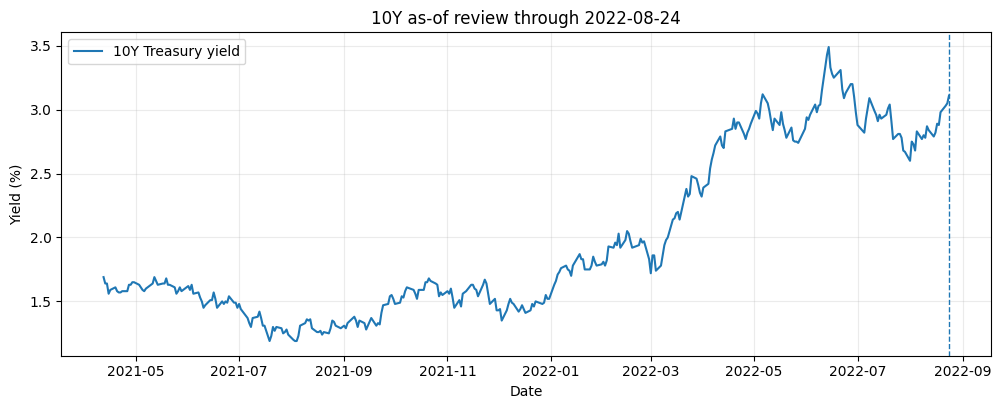

,series,value_bp,state
0,Recent 1M,14.2,Rising
1,Trend 6M,104.0,Rising
2,Trend 9M,141.2,Rising
3,Trend 12M,175.2,Rising


In [15]:
def nearest_common_row(tenor, as_of):
    as_of = pd.Timestamp(as_of)
    g = common.loc[
        (common["representative_tenor"] == tenor)
        & (common["as_of"] <= as_of)
    ].sort_values("as_of")
    if g.empty:
        raise ValueError(f"No common-sample row for {tenor} on or before {as_of.date()}")
    return g.iloc[-1]

def as_of_review(tenor, as_of, lookback_calendar_days=500):
    row = nearest_common_row(tenor, as_of)
    actual_date = row["as_of"]
    start = actual_date - pd.Timedelta(days=lookback_calendar_days)

    hist = (
        features_all.loc[
            (features_all["representative_tenor"] == tenor)
            & features_all["as_of"].between(start, actual_date)
        ]
        .sort_values("as_of")
    )

    plt.figure(figsize=(12, 4.2))
    plt.plot(hist["as_of"], hist["yield_pct"], label=f"{tenor} Treasury yield")
    plt.axvline(actual_date, linestyle="--", linewidth=1)
    plt.title(f"{tenor} as-of review through {actual_date.date()}")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    values = [{
        "series": "Recent 1M",
        "value_bp": row["recent_move_bp"],
        "state": row["recent_move_state"],
    }]
    for horizon in HORIZONS:
        values.append({
            "series": f"Trend {horizon}",
            "value_bp": row[f"trend_{horizon}_bp"],
            "state": row[f"trend_{horizon}_state"],
        })

    display(pd.DataFrame(values).round({"value_bp": 1}))

# Main challenge examples.
as_of_review("10Y", "1980-08-01")
as_of_review("30Y", "1980-08-01")
as_of_review("10Y", "2022-08-01")
as_of_review("10Y", "2022-08-24")


# Review checklist

Use the evidence above to answer the horizon question without turning it into an optimization exercise.

### 1. Is each candidate materially broader than Recent Move?

Transition frequency, episode persistence, and the frequency with which Recent changes while Trend remains unchanged should establish this quantitatively.

### 2. Does a longer horizon add useful economic separation?

Pay particular attention to 2022 10Y:

- Does 6M already preserve a broad `Rising` Trend while Recent becomes `Falling`?
- If yes, what additional useful information is gained by 9M or 12M?

### 3. Does a longer horizon become too inert?

Pay particular attention to 1980 10Y / 30Y:

- Does 12M keep the same broad State through economically substantial multi-month moves?
- If so, is that still a useful broad-Trend / Recent decomposition, or does too much economically relevant movement get delegated to Recent?

### 4. Do not choose from State occupancy alone

The fixed ±25 bp threshold interacts with horizon length. The horizon should be selected first; State Classification should be reviewed afterward.

### 5. Do not penalize mixed states mechanically

`Rising × Falling` and `Falling × Rising` are intended cases. Their frequency and duration are evidence to interpret, not errors to minimize.

### 6. Possible outcomes

```text
6M preferred
9M preferred
12M preferred
inconclusive
```

If the endpoint-horizon comparison is satisfactory, stop there. Do not introduce path-shape or moving-average Trend logic unless a concrete Duration-evaluation failure remains after this review.


# Review results

The checklist above asks what the evidence should establish. The results below collect the notebook's answers in the same order.

### 1. Is each candidate materially broader than Recent Move? — **Yes**

All three Trend horizons are already much slower than Recent Move. For 10Y, transition rates are **2.88% / 2.51% / 1.82%** for 6M / 9M / 12M versus **7.27%** for Recent Move; for 30Y they are **2.99% / 2.68% / 2.16%** versus **7.77%**.

The stronger separation check points the same way: about **96–98% of Recent-Move State changes occur while Trend remains unchanged** across all tested horizons. Therefore **6M already satisfies the broad-vs-recent role separation**; 9M or 12M is not needed merely to make Trend different from Recent Move.

### 2. Does a longer horizon add useful economic separation? — **Not enough to justify the added inertia**

Longer horizons do create more and longer opposing-direction cases. For example, 10Y `Rising × Falling` observations rise from **1,162 under 6M** to **1,713 under 12M**, and the median episode length rises from **7** to **10** observations.

But that statistic is ambiguous: it can mean useful broad-vs-recent separation, or it can mean that Trend is retaining an older regime. The Historical challenge plots are therefore the relevant check. They should be read as asking whether the added persistence still describes the **current broader condition**, not whether it merely increases disagreement with Recent Move.

### 3. Does a longer horizon become too inert? — **This is the main cost of 9M / 12M**

The aggregate statistics already show steadily lower transition rates as the horizon lengthens, while the challenge periods are designed to expose when that persistence becomes stale. The 1980 reversal is the clearest inertia test; the 2008 and 2020 shock/reversal windows provide additional stress cases.

The practical review question in those panels is simple: if Recent Move and the underlying yield have moved materially for weeks or months while 9M/12M still describe the old broad State, the extra horizon length is no longer adding useful context. This is the principal reason to prefer the shorter candidate unless a longer horizon demonstrates a compensating benefit.

### 4. Can State occupancy choose the horizon? — **No**

The continuous-value distribution widens mechanically with horizon. For 10Y, median `|Trend|` rises from **45.8 bp → 55.2 bp → 68.0 bp** across 6M / 9M / 12M, while the classification boundary stays fixed at ±25 bp.

Accordingly, 10Y `Stable` occupancy falls from **30.6% → 24.6% → 19.5%**. That does not show that 12M is a better Trend; it partly reflects using the same threshold on a larger-magnitude value. Horizon selection and State Classification should therefore remain separate decisions.

### 5. Are mixed States a problem? — **No**

Mixed Trend × Recent cases are an intended part of the design. Their frequency or duration should not be minimized mechanically. The question is whether they represent a useful decomposition of broader direction and recent movement.

Changing the horizon materially changes Rule Cases — for 10Y, **32.2%** of dates differ between 6M and 9M and **37.7%** between 6M and 12M — so the choice matters. But cross-tenor disagreement remains near **76%** under all three horizons, showing that the exposure-local structure itself is not collapsing.

## Overall result — **6M preferred, provisionally**

The evidence does **not** show a problem that requires lengthening Trend to 9M or 12M:

- 6M is already materially slower than Recent Move.
- 6M already preserves mixed broad-vs-recent conditions.
- 9M and 12M mainly add persistence, while also increasing the risk of stale-regime attribution during reversals.
- State-frequency differences are confounded by the mechanical scale effect of horizon length.
- The horizon choice materially changes downstream Rule Cases, so added inertia should require a clear economic benefit; this review does not establish one.

Therefore the current horizon decision is:

```text
6M preferred
```

This remains a **horizon / endpoint-construction conclusion**, not acceptance of the fixed ±25 bp Trend State Classification. Review State Classification separately after the horizon decision.
